# D6 · Aerodynamics: AeroBuildup, a hand check, and the tiltrotor-specific pieces

Drag is the single input that moves payload headroom the most (the README says so), so the aerodynamics deserve a
careful look: where the numbers come from, what they are calibrated against, and what they are not.

**What you will learn**
1. The three interchangeable aerodynamic models (simple polar, AeroSandbox AeroBuildup, Scholz hand build-up), and
   why AeroBuildup is the default.
2. The cruise drag of the sized aircraft, component by component.
3. The drag calibration: an excrescence factor that matches NASA's NDARC XV-15 drag.
4. Tiltrotor pieces: the blown wing (coupled without iteration), trim drag from the tail load, and the hover
   download.

**Run time:** about a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft, build_halo_aerodynamics
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.aerodynamics.scholz import ScholzAerodynamics
from aircraft_closure.aerodynamics.buildup import BuildupAerodynamics
from aircraft_closure.aerodynamics.slipstream import RotorState

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
aero = build_halo_aerodynamics(requirements, assumptions)        # the sizing's model: AeroBuildup + corrections
print(type(aero).__name__, "| excrescence", aero.factor_excrescence, "| trim:", type(aero.trim).__name__,
      "| blown wing:", type(aero.blown_wing).__name__)

BuildupAerodynamics | excrescence 1.27 | trim: TailTrim | blown wing: BlownWing


## 1. One interface, three models

Every aerodynamic model takes the aircraft, airspeed, altitude and angle of attack and returns the same `AeroResult`
(CL, CD, CD0, CDi, L/D, lift-curve slope, ...), so the sizing can swap them with one assumption
(`HaloAssumptions.aerodynamics_model`):

| Model | What it is | Role |
|---|---|---|
| `SimpleAerodynamics` | linear lift, a component-wise parasite build-up (flat-plate skin friction, form factors) plus a **guessed** miscellaneous drag area, Oswald induced drag | the first rung (plan 006); kept |
| `BuildupAerodynamics` | AeroSandbox **AeroBuildup** on the actual geometry: NeuralFoil section polars (Re, Mach, post-stall), body form factors, plus Scholz interference factors, an excrescence factor, trim drag from the tail load, the blown wing and a geometric hover download | **the default** (plan 027) |
| `ScholzAerodynamics` | a closed-form hand build-up from Scholz's *Aircraft Design* ch. 13, every equation citable | the independent check, and the cheap warm start for the AeroBuildup sizing |

The author's direction (plan 025) was "lean heavily on AeroSandbox's built-in aerodynamics": the framework fills only
what AeroBuildup lacks. All three are written in `aerosandbox.numpy`, so they are differentiable inside the sizing; an
AeroBuildup evaluation costs about 30 ms numerically.

The airplane AeroBuildup sees is generated from the vehicle objects (`aircraft.to_asb()`):

lifting surfaces: ['wing', 'horizontal_tail', 'vertical_tail'] | bodies: ['fuselage', 'nacelle_right', 'nacelle_left']


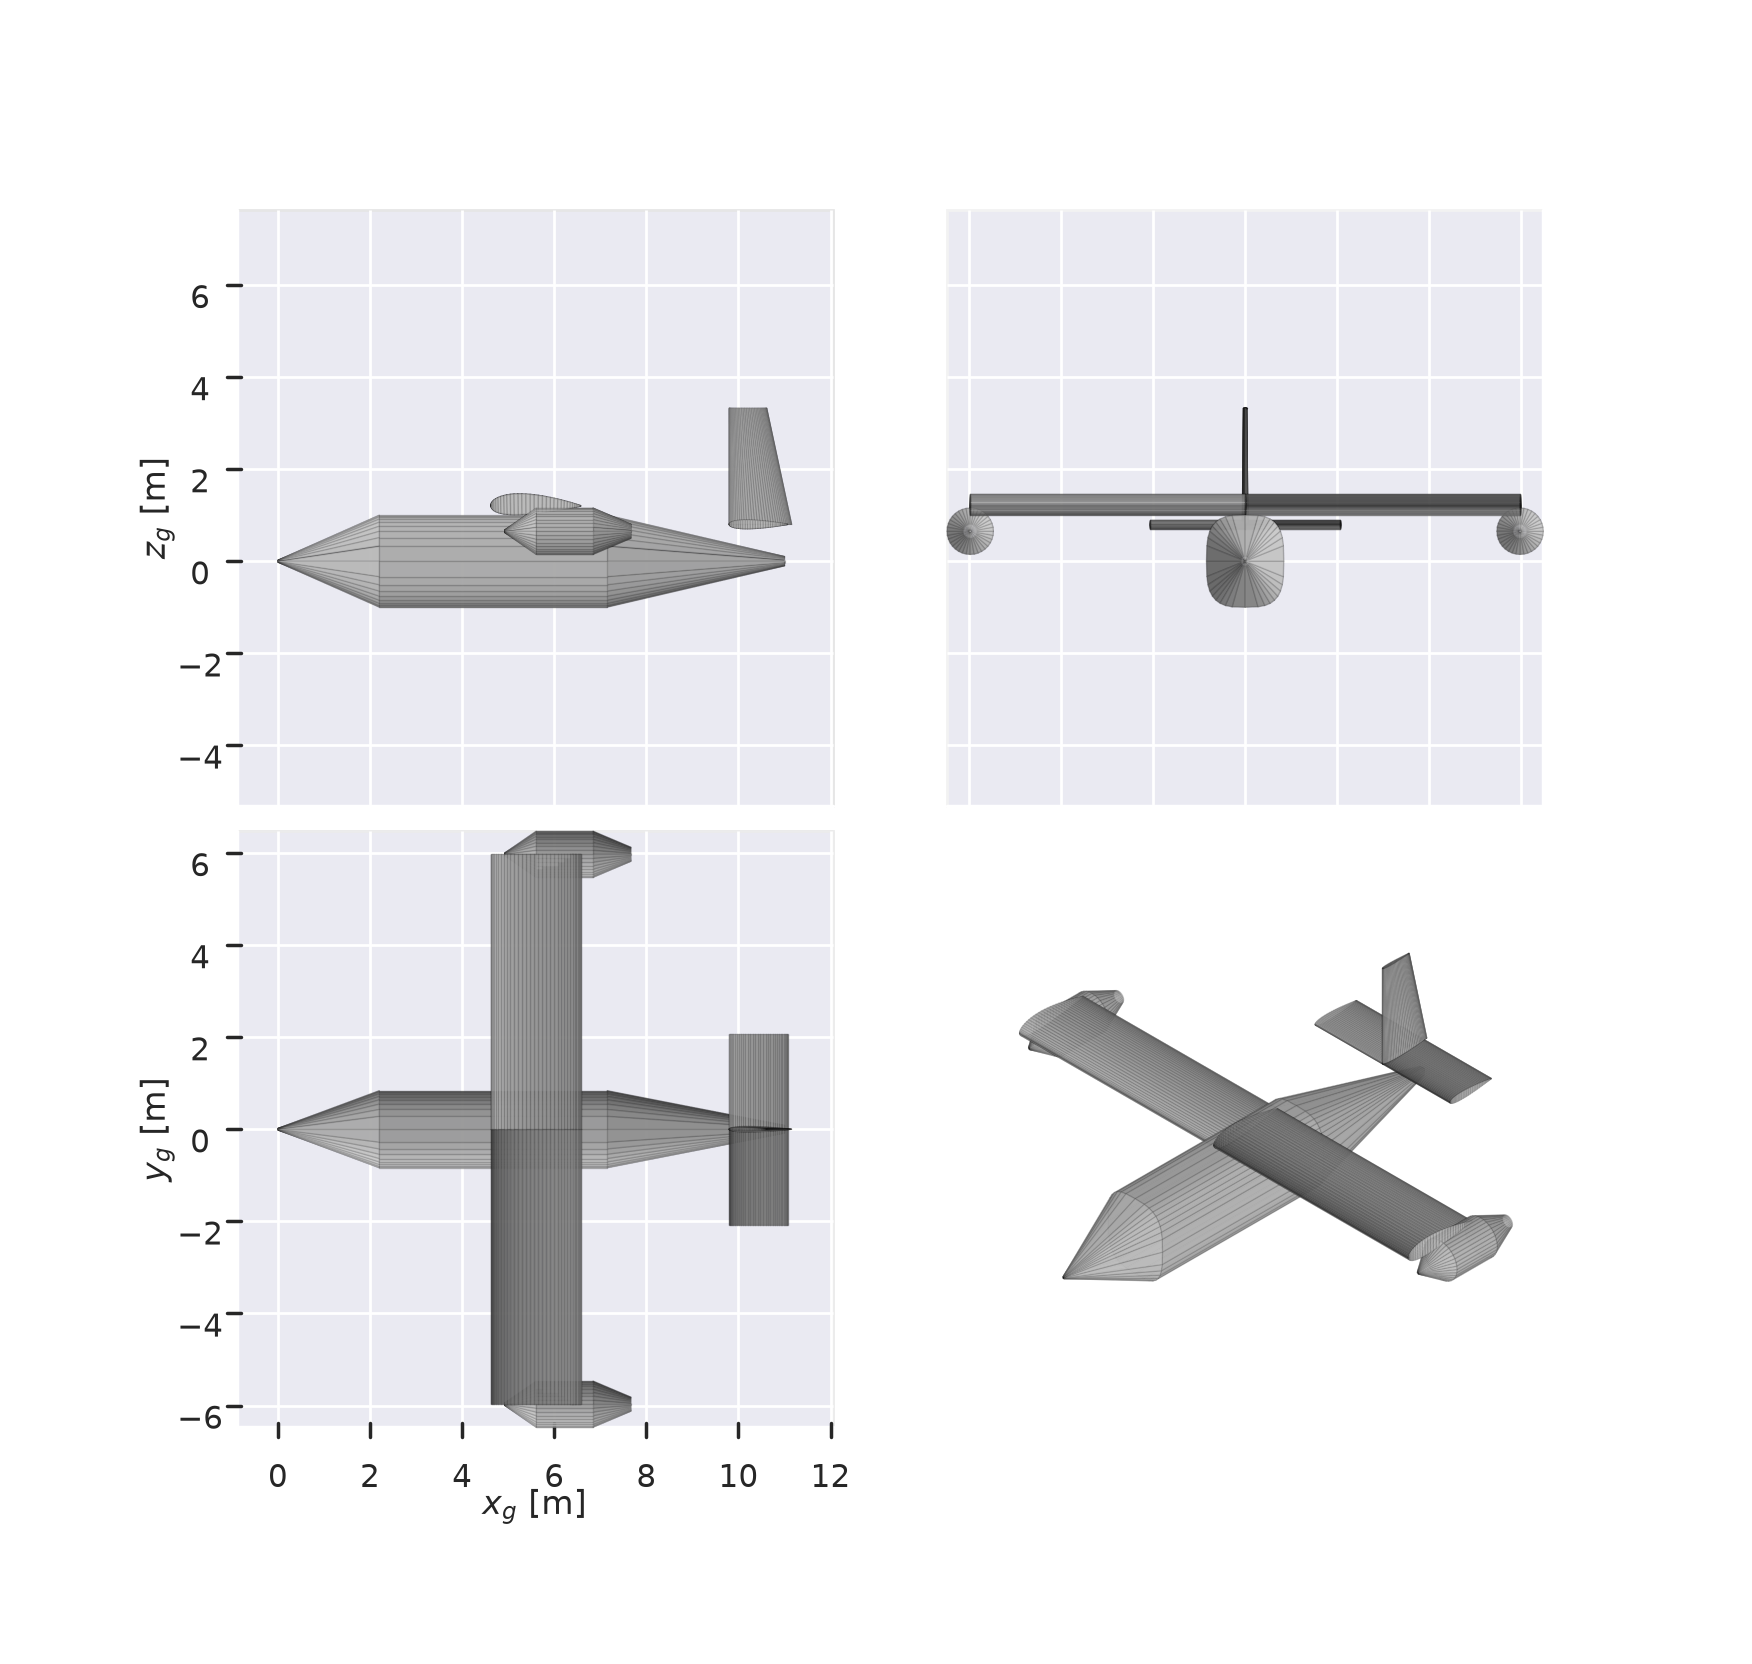

In [2]:
airplane = aircraft.to_asb()
print("lifting surfaces:", [w.name for w in airplane.wings], "| bodies:", [f.name for f in airplane.fuselages])
airplane.draw_three_view(show=False)
plt.gcf().set_size_inches(8, 7); plt.show()
apply_style()                      # AeroSandbox's drawing changes the global plot style; restore ours

## 2. The cruise point of the sized aircraft

Rebuild the start of cruise: 165 kt at 10,000 ft, at the mass after take-off and climb, with the rotors' slipstream
on the wing. The angle of attack is solved for lift = weight, exactly as the flight point does it (one variable, one
equality).

In [3]:
cruise = next(s for s in ref.segments if s["label"] == "cruise")
take_off, climb = ref.segments[0], ref.segments[1]
mass_kg = ref.mass_takeoff_kg - take_off["fuel_kg"] - climb["fuel_kg"]
velocity_m_s, altitude_m = cruise["velocity_m_s"], cruise["altitude_start_m"]
speed_rotor_rad_s = next(w for w in ref.whirl_flutter if w["label"].startswith("cruise"))["speed_rotor_rad_s"]

def solve_alpha(model, rotor_state=None):
    opti = asb.Opti()
    alpha_deg = opti.variable(init_guess=3.0)
    result = model.evaluate(aircraft, velocity_m_s, altitude_m, alpha_deg, rotor_state=rotor_state) \
        if isinstance(model, BuildupAerodynamics) else model.evaluate(aircraft, velocity_m_s, altitude_m, alpha_deg)
    opti.subject_to(result.lift_N / (mass_kg * 9.80665) == 1)
    solution = opti.solve(verbose=False)
    return scalar(solution.value(alpha_deg)), {k: scalar(solution.value(getattr(result, k))) for k in ("cl", "cd", "cd0", "cdi", "lift_to_drag", "drag_N")}

# Thrust per rotor is coupled to drag; one pass is enough here to set the slipstream for a display.
alpha0, r0 = solve_alpha(aero, RotorState(3.7e3, speed_rotor_rad_s))
alpha_deg, r = solve_alpha(aero, RotorState(r0["drag_N"] / 2, speed_rotor_rad_s))
print(f"alpha {alpha_deg:.2f} deg, CL {r['cl']:.3f}, CD {r['cd']:.5f} (CD0 {r['cd0']:.5f}, CDi {r['cdi']:.5f}), L/D {r['lift_to_drag']:.2f}")
print(f"sizing reported: CL {ref.cl_cruise:.3f}, L/D {ref.lift_to_drag_cruise:.2f}")
check("the rebuilt cruise point matches the sizing's L/D within 1 %", abs(r["lift_to_drag"] / ref.lift_to_drag_cruise - 1) < 0.01)

alpha 6.64 deg, CL 0.878, CD 0.09685 (CD0 0.04163, CDi 0.05231), L/D 9.07
sizing reported: CL 0.878, L/D 9.07
PASS  the rebuilt cruise point matches the sizing's L/D within 1 %


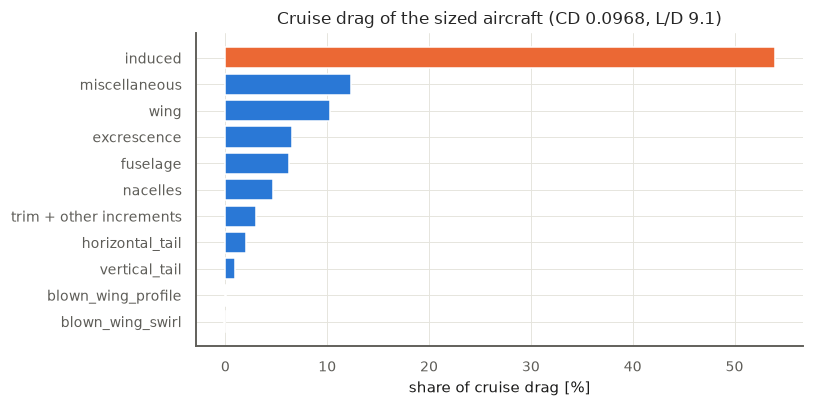

   induced                   0.05231  (54.0%)
   miscellaneous             0.01196  (12.4%)
   wing                      0.00994  (10.3%)
   excrescence               0.00632  ( 6.5%)
   fuselage                  0.00600  ( 6.2%)
   nacelles                  0.00457  ( 4.7%)
   trim + other increments   0.00290  ( 3.0%)
   horizontal_tail           0.00199  ( 2.1%)
   vertical_tail             0.00090  ( 0.9%)
   blown_wing_profile        0.00008  ( 0.1%)
   blown_wing_swirl          -0.00015  (-0.2%)


In [4]:
detail = aero.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha_deg,
                               rotor_state=RotorState(r["drag_N"] / 2, speed_rotor_rad_s))
items = [(item.label, scalar(item.cd0)) for item in detail.breakdown]
total_cd = scalar(detail.aero.cd)
items.append(("induced", scalar(detail.aero.cdi)))
items.append(("trim + other increments", total_cd - sum(v for _, v in items)))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
labels, values = zip(*sorted(items, key=lambda item: item[1]))
ax.barh(labels, [v / total_cd * 100 for v in values], color=[orange if l == "induced" else blue for l in labels])
ax.set(xlabel="share of cruise drag [%]", title=f"Cruise drag of the sized aircraft (CD {total_cd:.4f}, L/D {scalar(detail.aero.lift_to_drag):.1f})")
plt.tight_layout(); plt.show()
for label, value in sorted(items, key=lambda item: -item[1]):
    print(f"   {label:<26}{value:.5f}  ({value / total_cd:5.1%})")

Two things stand out. **Induced drag is about half the total**: the cruise speed is a design variable, and the
optimizer chose one (165 kt) close to the speed for maximum L/D, where induced and parasite drag are about equal. And
that maximum L/D is modest (about 9) for tiltrotor reasons: a low aspect ratio (6.1, the XV-15's), a thick 23 % wing
for stiffness against whirl flutter, nacelles and spinners on the tips, a boxy fuselage. The
"miscellaneous" item is the XV-15's 3 ft² of fittings and fixtures (NDARC), carried as a fixed drag area. And note the
**excrescence** item: it is a calibration, not physics (next section).

## 3. Calibrating drag to NDARC's XV-15

AeroBuildup and the Scholz hand build-up both leave out excrescences, leakage and protuberances. Plan 034 adds them as
a factor on the component drag, **calibrated** so that the XV-15's wing, tails, fuselage and pylons match NASA's NDARC
estimate of 6.25 ft² (Johnson 2010, Table 1):

In [5]:
from examples.xv15_reference import Xv15Reference, build_xv15_aircraft
from aircraft_closure.aerodynamics.scholz import InterferenceFactors
xv15_ref = Xv15Reference()
xv15 = build_xv15_aircraft(xv15_ref, mass_engine_kg=300.0)
xv15 = replace(xv15, nacelles=replace(xv15.nacelles, length_m=9 * u.foot, diameter_m=3.3 * u.foot, y_m=xv15.wing.span_m() / 2))
h_tail = InterferenceFactors(horizontal_tail=1.08, vertical_tail=1.08)      # Scholz Table 13.4, H-tail

def drag_area_ft2(model):
    result = model.evaluate(xv15, xv15_ref.velocity_cruise_m_s, xv15_ref.altitude_cruise_m, 0.0)
    return scalar(result.cd0) * xv15.wing.area_m2 / u.foot**2

for name, cls, factor in (("AeroBuildup", BuildupAerodynamics, assumptions.factor_excrescence_buildup),
                          ("Scholz", ScholzAerodynamics, assumptions.factor_excrescence_scholz)):
    clean = drag_area_ft2(cls(interference=h_tail))
    calibrated = drag_area_ft2(cls(interference=h_tail, factor_excrescence=factor))
    print(f"{name:<12} clean {clean:.2f} ft2 x {factor} = {calibrated:.2f} ft2   (NDARC 6.25 ft2)")
    check(f"{name} calibrated to NDARC's XV-15 within 1 %", abs(calibrated / 6.25 - 1) < 0.01)

AeroBuildup  clean 4.94 ft2 x 1.27 = 6.27 ft2   (NDARC 6.25 ft2)
PASS  AeroBuildup calibrated to NDARC's XV-15 within 1 %
Scholz       clean 5.34 ft2 x 1.17 = 6.25 ft2   (NDARC 6.25 ft2)
PASS  Scholz calibrated to NDARC's XV-15 within 1 %


Two independent build-ups need 27 % and 17 % on top of their clean components to reach the same number. That is
typical: clean build-ups under-predict real aircraft drag. But note **what the calibration target is: another
model (NDARC), not flight test.** The README lists this as the top aerodynamic limitation: *"Drag is anchored to
NASA NDARC's XV-15 estimate, not to flight data, and drag drives payload headroom more than anything else."*

## 4. Tiltrotor-specific pieces

### 4a. The blown wing, coupled without iteration

In airplane mode each rotor's slipstream washes part of the wing (axial momentum theory for the induced velocity,
McCormick's slipstream development and contraction, the swirl angle). The increments are a lift gain, extra profile
drag in the faster flow, and a credit for recovered swirl (bounded by the swirl's own energy: the first version
credited 8× the available energy and was replaced).

The coupling is circular: the slipstream depends on thrust, thrust equals drag, drag depends on the slipstream. The
flight point does not iterate: **thrust per rotor is an optimization variable** and an equality ties it to the
drag. One more variable, one more equation, exact derivatives.

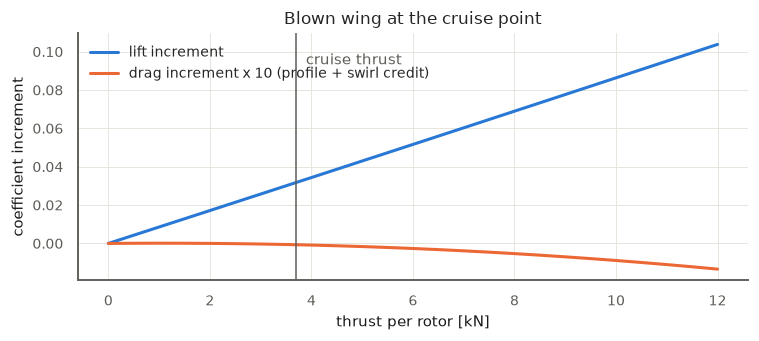

PASS  zero thrust gives zero increments


In [6]:
thrusts = np.linspace(0, 12e3, 25)
dcl, dcd = [], []
for thrust_N in thrusts:
    blown = aero.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha_deg, rotor_state=RotorState(thrust_N, speed_rotor_rad_s)).blown
    dcl.append(scalar(blown.delta_cl)); dcd.append(scalar(blown.delta_cd_profile + blown.delta_cd_swirl))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(thrusts / 1e3, dcl, color=blue, lw=2, label="lift increment")
ax.plot(thrusts / 1e3, np.array(dcd) * 10, color=orange, lw=2, label="drag increment x 10 (profile + swirl credit)")
ax.axvline(r["drag_N"] / 2e3, color=ink_muted, lw=1); ax.text(r["drag_N"] / 2e3 + 0.2, max(dcl) * 0.9, "cruise thrust", color=ink_muted)
ax.set(xlabel="thrust per rotor [kN]", ylabel="coefficient increment", title="Blown wing at the cruise point")
ax.legend(); plt.tight_layout(); plt.show()
check("zero thrust gives zero increments", abs(dcl[0]) < 1e-12 and abs(dcd[0]) < 1e-12)

At cruise thrust the effect is small (with and without blowing the design differed by 7 lb in plan 027); it matters
more at high thrust, in climb and conversion.

### 4b. Trim drag from the tail load

The tail must carry the load that trims the pitching moment about the CG, and that load costs induced drag on the
tail and changes the wing's. `TailTrim` (plan 036, Scholz ch. 11) computes the tail lift needed to trim AeroBuildup's
moment about the CG, and its drag. One subtlety: AeroBuildup's tail sees the free-stream angle (no wing downwash), so
its nose-down moment is too large; a downwash correction (ε = 1.75 CL/πA) fixes it. Without it, trim drag came out at
about 7 % of the total; with it, under 2 %.

In [7]:
from aircraft_closure.aerodynamics.trim import TailTrim
untrimmed = replace(aero, trim=None)
print(f"{'alpha':>6}{'CL':>8}{'trim drag share':>18}")
for a_deg in (0.0, 2.0, 4.0, 6.0, 8.0):
    with_trim = aero.evaluate(aircraft, velocity_m_s, altitude_m, a_deg)
    without = untrimmed.evaluate(aircraft, velocity_m_s, altitude_m, a_deg)
    print(f"{a_deg:6.1f}{scalar(with_trim.cl):8.3f}{(scalar(with_trim.cd) - scalar(without.cd)) / scalar(with_trim.cd):17.1%}")

 alpha      CL   trim drag share
   0.0   0.212            -0.1%


   2.0   0.405             0.3%
   4.0   0.598             1.4%


   6.0   0.787             2.8%
   8.0   0.970             4.4%


### 4c. Hover download

In hover the rotor wake hits the wing, pushing down. The constant 7 % of the early versions (the XV-15's measured
value) was replaced by a geometric model (NDARC form): the download fraction is a vertical drag coefficient times the
wing area immersed in the contracted wake, over the disk area. The coefficient is calibrated so the XV-15 geometry
gives exactly 7 % with flaps down. Now a bigger wing chord or a smaller rotor raises the download, and the optimizer
sees it.

In [8]:
from aircraft_closure.aerodynamics.download import HoverDownload, download_fraction
chord_xv15_m = 168.88 * u.foot**2 / (32.17 * u.foot)
print(f"XV-15 (flaps 60 deg): {scalar(download_fraction(chord_xv15_m, 12.5 * u.foot, 2)):.4f}")
print(f"XV-15 (flaps 0 deg) : {scalar(download_fraction(chord_xv15_m, 12.5 * u.foot, 2, HoverDownload(deflection_flap_hover_deg=0.0))):.4f}")
print(f"sized Halo          : {scalar(aero.hover_download_fraction(aircraft)):.4f}")
check("the download model reproduces the XV-15's 7 %", abs(scalar(download_fraction(chord_xv15_m, 12.5 * u.foot, 2)) - 0.07) < 1e-4)

XV-15 (flaps 60 deg): 0.0700
XV-15 (flaps 0 deg) : 0.0800
sized Halo          : 0.0673
PASS  the download model reproduces the XV-15's 7 %


## 5. How the three models compare on the sized aircraft

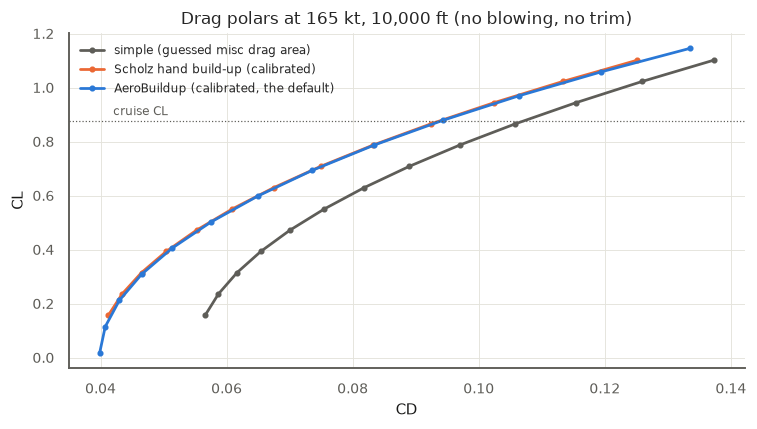

In [9]:
alphas = np.linspace(-2, 10, 13)
fig, ax = plt.subplots(figsize=(7, 4))
models = (("simple (guessed misc drag area)", SimpleAerodynamics(drag_area_misc_m2=assumptions.drag_area_misc_m2), ink_muted),
          ("Scholz hand build-up (calibrated)", ScholzAerodynamics(drag_area_misc_m2=assumptions.drag_area_misc_buildup_m2,
                                                                   factor_excrescence=assumptions.factor_excrescence_scholz), orange),
          ("AeroBuildup (calibrated, the default)", untrimmed, blue))
for label, model, color in models:
    results = [model.evaluate(aircraft, velocity_m_s, altitude_m, a_deg) for a_deg in alphas]
    ax.plot([scalar(x.cd) for x in results], [scalar(x.cl) for x in results], "o-", ms=3, color=color, lw=1.8, label=label)
ax.axhline(r["cl"], color=ink_muted, lw=0.8, ls=":"); ax.text(0.042, r["cl"] + 0.02, "cruise CL", color=ink_muted, fontsize=8)
ax.set(xlabel="CD", ylabel="CL", title="Drag polars at 165 kt, 10,000 ft (no blowing, no trim)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The simple model's guessed 0.8 m² miscellaneous drag area was most of the aircraft's drag. Replacing it with
AeroBuildup took the design from 14,247 to 13,639 lb (v3.1 → v3.2). The drag corrections later added back about 350
lb (plan 034): the version history is, among other things, a record of how sensitive the answer is to drag.

## Why it is built this way

- **AeroBuildup over a polar:** geometry-driven, Reynolds- and Mach-dependent section polars and form factors, all
  differentiable, so changing the wing or the fuselage changes drag the way it should. The guessed drag area of the
  simple model hid the dominant term in an assumption.
- **A hand build-up alongside:** an independent, citable check (they agree within about 2 % in CD0 calibrated),
  and a cheap, robust model to warm-start the AeroBuildup sizing from (core tutorial 20).
- **Couplings as variables:** blown wing (thrust variable), cooling drag (drag variable), trim (computed at the CG
  the hover trim fixes). No nested iteration anywhere.
- **Calibration as an explicit, labelled factor** against a published number, rather than tuning inputs until the
  answer looks right.

## What it can't do

- **Drag is calibrated to a model, not to flight data**; transition location and the fittings area are not validated.
- **No conversion-mode aerodynamics** in the sizing (airplane mode and hover only). The conversion corridor and the
  trajectories use the unblown polar.
- **No downwash at the tail** in AeroBuildup (corrected only in the trim drag); stability derivatives use analytic
  isolated-surface lift slopes, not AeroBuildup's (a possible double count of tail lift when
  the stability model is fed AeroBuildup's whole-aircraft CL; core tutorial 14 covers the stability model).
- **No compressibility drag rise** beyond what NeuralFoil carries (cruise is Mach 0.25-0.3, so this is minor).
- **Download** is hover only, with no ground effect, fountain flow or fuselage download.
- **The V-tail is drawn but not sized**: the baseline sizes a conventional tail (dihedral 0°); the cos Γ hook in the
  trim model is ready for it.

## What's next

From the README's aerodynamics work package, in order of information per unit time:

1. **Validate what exists:** VSPAERO (vortex lattice and panel) and AeroBuildup against XV-15 wind-tunnel and flight
   data; anchor drag to the XV-15 power-required curve. Size the V-tail.
2. Rotor-wing interaction with OpenVSP's prop modelling (download in hover, blown wing in cruise).
3. **Targeted CFD, later**, once the optimization target is defined: ADflow (with pyGeo, pyHyp, IDWarp) on the wing,
   the wing-nacelle junction or the aft body; CFD with the rotor modelled for the prop blowing over the wing.

## Check yourself

<details><summary>1. Why is the excrescence factor 1.27 for AeroBuildup and 1.17 for Scholz?</summary>

Each factor calibrates its own clean build-up to the same target, NDARC's 6.25 ft² for the XV-15's wing, tails,
fuselage and pylons. AeroBuildup's clean components came out lower (4.94 ft²) than Scholz's (5.34 ft²), so it needs
the larger factor.
</details>

<details><summary>2. How is the blown wing coupled without a fixed-point iteration?</summary>

Thrust per rotor becomes an optimization variable passed into the aerodynamics (it sets the slipstream), and an
equality constraint ties total thrust to total drag. IPOPT satisfies it together with everything else.
</details>

<details><summary>3. Why replace a 7 % download (measured on the XV-15) with a geometric model?</summary>

A constant hides the physics from the optimizer: with it, a bigger wing chord or a smaller rotor costs nothing in
hover. The geometric model, calibrated to give 7 % on the XV-15, makes that cost visible.
</details>

In [10]:
check_summary()

5 of 5 checks passed
